# English → Auslan pose: SFT on Auslan-Daily Communication

Trains `auslan_sft/` (text → pose generator initialised from the Uni-Sign OpenASL pose-only checkpoint) on the **Communication** subset of Auslan-Daily only.

- Data: the rtmlib poses already on Drive (`auslan_work/pose/chunk_*.tar`); no video is read and no pose is re-extracted.
- Split: the **official** Auslan-Daily split (train 12,440 / val 800 / test 800 before exclusions). This keeps back-translation valid: the Uni-Sign SLT model used as the evaluator was trained on the official train split only.
- `excluded.txt` (mirrored / wrong-person tracking) is dropped from train and val only; test stays complete, as for the SLT runs.
- About 30% of val/test clips repeat a sentence that also occurs in train. Section 10 reports **seen** and **unseen** sentences separately; only the unseen rows say anything about generalisation.
- Training: `configs/auslan_sft.yaml` defaults (mode B, bf16, batch 16, up to 60 epochs, early stopping on free-running val DTW, patience 8).

Run the cells in order. After a disconnect, re-run sections 1–7, then 8 (it resumes from `latest.pt`, losing at most the unfinished epoch).

## 1. Runtime and dependencies

In [1]:
import subprocess
print(subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True).stdout.strip() or 'NO GPU')
DEVICE = 'cuda'

!pip -q install sentencepiece einops sacrebleu
import torch, transformers
print('torch', torch.__version__, '| transformers', transformers.__version__, '| cuda', torch.cuda.is_available())
if not torch.cuda.is_available():
    raise SystemExit('CUDA is required')

NVIDIA A100-SXM4-40GB, 40960 MiB
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.6/129.6 kB 11.5 MB/s eta 0:00:00
torch 2.11.0+cu128 | transformers 5.16.1 | cuda True


## 2. Mount Drive

In [2]:
import os, glob, json, csv, copy, hashlib, shutil, signal, subprocess, sys, tarfile
from google.colab import drive
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive'
WORK = f'{DRIVE}/auslan_work'
MANIFEST = f'{WORK}/manifest.jsonl'
EXCLUDE = f'{WORK}/excluded.txt'
AD_EXCLUDE = f'{WORK}/excluded_auslan_daily.txt'
SFT_WORK = f'{WORK}/sft/communication'          # annotations, splits, configs, normalised-pose cache
os.makedirs(SFT_WORK, exist_ok=True)
for path in (MANIFEST, EXCLUDE):
    if not os.path.exists(path):
        raise SystemExit(f'{path} is missing')
if not glob.glob(f'{WORK}/pose/chunk_*.tar'):
    raise SystemExit(f'no pose chunks in {WORK}/pose')
print('work dir:', WORK)

Mounted at /content/drive
work dir: /content/drive/MyDrive/auslan_work


## 3. Copy the code

Needs `auslan_sft/` and `unisign/` on Drive (folders, or `auslan_sft_code.tar.gz` / `unisign_code.tar.gz`). Both go under `/content/` side by side: back-translation imports `../unisign/model_adapter.py` relative to `auslan_sft/`, and the config's `../Uni-Sign` / `../checkpoints` paths assume the same layout.

In [3]:
def locate(parts):
    for root in (DRIVE, '/content'):
        for prefix in ('', '*/', '*/*/'):
            hits = [h for h in glob.glob(os.path.join(root, prefix, *parts)) if not h.startswith('/content/_code')]
            if hits:
                return hits[0]
    return None

def install(name, marker, tarball):
    dst = f'/content/{name}'
    src = locate([name, marker])
    if src:
        src = os.path.dirname(src)
    else:
        tb = locate([tarball])
        if tb is None:
            raise SystemExit(f'Upload {name}/ or {tarball} to Drive first')
        shutil.rmtree(f'/content/_code/{name}', ignore_errors=True)
        with tarfile.open(tb) as tf:
            tf.extractall('/content/_code', filter='data')
        src = f'/content/_code/{name}'
    if os.path.abspath(src) != dst:
        shutil.rmtree(dst, ignore_errors=True)
        shutil.copytree(src, dst, ignore=shutil.ignore_patterns('__pycache__', '*.ipynb', 'data', 'checkpoints', 'outputs'))
    print(f'{name}: from {src}')
    return dst

SFT = install('auslan_sft', 'train.py', 'auslan_sft_code.tar.gz')
UNISIGN_CODE = install('unisign', 'spec.py', 'unisign_code.tar.gz')
for f in ('slp_utils/back_translation.py', 'preprocessing/annotations_from_manifest.py', 'verify_checkpoint.py', 'evaluate.py', 'infer.py'):
    assert os.path.exists(f'{SFT}/{f}'), f'{f} missing from {SFT}'
assert os.path.exists(f'{UNISIGN_CODE}/model_adapter.py'), 'unisign/model_adapter.py missing'

auslan_sft: from /content/_code/auslan_sft
unisign: from /content/drive/MyDrive/unisign


## 4. Pretrained assets (pinned, sha256-checked)

- generator initialisation: `openasl_pose_only_slt.pth`, Uni-Sign repo `eed438b`, `google/mt5-base`;
- evaluator for back-translation: the OpenASL Arm A SLT run (Communication val BLEU-4 18.03 on real poses). If it is missing, sections 10–11 still run, without back-translation.

In [4]:
from huggingface_hub import hf_hub_download, snapshot_download

INIT_CKPT = 'openasl_pose_only_slt.pth'
REPO_DIR = '/content/Uni-Sign'
REPO_COMMIT = 'eed438bcb49e30405cd6ccdfcccca330c134e830'
MT5_DIR = f'{REPO_DIR}/pretrained_weight/mt5-base'
MT5_REVISION = '2eb15465c5dd7f72a8f7984306ad05ebc3dd1e1f'
UNISIGN_REVISION = 'eab251b7fe7e8521afc0e67be98add670ea40a0d'
SHA256 = {
    'openasl_pose_only_slt.pth': 'f836ea66bc837bbe6ed717a4b9bece87875f03ef96d4bf1092ca3dd767982798',
    'mt5-base/pytorch_model.bin': '180573b534144580f04af026da62bf71bc976ee1b7eb311b8945e2fefde8d614',
}

if not os.path.isdir(f'{REPO_DIR}/.git'):
    subprocess.run(['git', 'clone', '-q', 'https://github.com/ZechengLi19/Uni-Sign.git', REPO_DIR], check=True)
subprocess.run(['git', '-C', REPO_DIR, 'checkout', '-q', REPO_COMMIT], check=True)
snapshot_download('google/mt5-base', revision=MT5_REVISION, local_dir=MT5_DIR, allow_patterns=['*.json', '*.model', 'pytorch_model.bin'])
CKPT = hf_hub_download('ZechengLi19/Uni-Sign', INIT_CKPT, revision=UNISIGN_REVISION, local_dir='/content/checkpoints')

def sha256(path):
    h = hashlib.sha256()
    with open(path, 'rb') as f:
        for block in iter(lambda: f.read(1 << 24), b''):
            h.update(block)
    return h.hexdigest()

for name, path in [(INIT_CKPT, CKPT), ('mt5-base/pytorch_model.bin', f'{MT5_DIR}/pytorch_model.bin')]:
    if sha256(path) != SHA256[name]:
        raise SystemExit(f'{name}: sha256 mismatch')
    print('OK', name)

SLT_RUN = 'arm_a__openasl_pose_only_slt__official_stage3__single_a100__bf16'
SLT_CKPT = f'{WORK}/runs/{SLT_RUN}/checkpoint.pt'
if os.path.exists(SLT_CKPT):
    print('back-translation evaluator:', SLT_CKPT)
else:
    SLT_CKPT = None
    print(f'WARNING: {WORK}/runs/{SLT_RUN}/checkpoint.pt not found; evaluation will skip back-translation')

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

openasl_pose_only_slt.pth: reconstructing file:   0%|          |  0.00B / 1.19GB            

openasl_pose_only_slt.pth: downloading bytes:           |  0.00B            

OK openasl_pose_only_slt.pth
OK mt5-base/pytorch_model.bin
back-translation evaluator: /content/drive/MyDrive/auslan_work/runs/arm_a__openasl_pose_only_slt__official_stage3__single_a100__bf16/checkpoint.pt


## 5. Annotations (Communication only) and config

`excluded.txt` must hold exactly the 131 Auslan-Daily uids; if a later verify pass overwrote it, it is repaired from `excluded_auslan_daily.txt` (same gate as the SLT notebooks). All paths in the written config are absolute, so it works from any directory.

In [5]:
import yaml

EXPECTED_AD_EXCLUSIONS = 131
def read_ids(path):
    return {line.strip() for line in open(path) if line.strip() and not line.startswith('#')}
def valid_gate(ids):
    return len(ids) == EXPECTED_AD_EXCLUSIONS and all(u.startswith('ad-') for u in ids)

excluded = read_ids(EXCLUDE)
if not valid_gate(excluded):
    protected = read_ids(AD_EXCLUDE) if os.path.exists(AD_EXCLUDE) else set()
    if not valid_gate(protected):
        raise SystemExit(f'excluded.txt holds {len(excluded)} uids, expected exactly {EXPECTED_AD_EXCLUSIONS} ad- uids, '
                         'and no valid excluded_auslan_daily.txt exists')
    shutil.copyfile(AD_EXCLUDE, EXCLUDE)
    excluded = protected
    print('excluded.txt repaired from', AD_EXCLUDE)

ANN_ALL = f'{SFT_WORK}/annotations_all.csv'
ANN = f'{SFT_WORK}/annotations.csv'
subprocess.run([sys.executable, 'preprocessing/annotations_from_manifest.py', '--manifest', MANIFEST,
                '--out', ANN_ALL, '--subsets', 'communication'], cwd=SFT, check=True)
with open(ANN_ALL, newline='', encoding='utf-8') as fh:
    all_rows = list(csv.DictReader(fh))
# Drop the gate's clips from train/val only; test stays complete (same protocol as the SLT runs).
ann_rows = [r for r in all_rows if not (r['uid'] in excluded and r['split'] in ('train', 'val'))]
with open(ANN, 'w', newline='', encoding='utf-8') as fh:
    w = csv.DictWriter(fh, fieldnames=list(all_rows[0]))
    w.writeheader(); w.writerows(ann_rows)
count = lambda rows, s: sum(r['split'] == s for r in rows)
print(f'communication: {len(all_rows)} clips -> {len(ann_rows)} after exclusions')
for s in ('train', 'val', 'test'):
    print(f'  {s:<5} {count(all_rows, s):>6} -> {count(ann_rows, s):>6}')
if len(all_rows) != 14040:
    raise SystemExit('expected 14,040 Communication clips in the manifest')

RUN = 'sft_comm__openasl__modeB__seed42'
RAW_POSE = '/content/sft_raw_pose'        # restored unisign .npz (local disk)
POSE = '/content/sft_pose'                # normalised .pt (local disk; cached on Drive in section 6)
OUT = f'{WORK}/sft_runs/{RUN}'

CFG = yaml.safe_load(open(f'{SFT}/configs/auslan_sft.yaml'))
CFG['data'].update(annotations_csv=ANN, video_root=SFT_WORK, id_column='uid',
                   raw_pose_dir=RAW_POSE, pose_dir=POSE, split_dir=f'{SFT_WORK}/splits')
CFG['split'].update(method='column', split_column='split')
CFG['pretrained'].update(unisign_checkpoint=CKPT, unisign_repo=REPO_DIR, mt5_dir=MT5_DIR)
CFG['training'].update(output_dir=OUT, device=DEVICE, num_workers=8)
CFG_PATH = f'{SFT_WORK}/configs/{RUN}.yaml'
os.makedirs(os.path.dirname(CFG_PATH), exist_ok=True)
with open(CFG_PATH, 'w') as fh:
    yaml.safe_dump(CFG, fh, sort_keys=False)
print('config:', CFG_PATH)
print(yaml.safe_dump({k: CFG[k] for k in ('data', 'split', 'pretrained')}, sort_keys=False))
print('training:', {k: CFG['training'][k] for k in ('mode', 'epochs', 'batch_size', 'precision', 'lr_pretrained', 'lr_new')})

subprocess.run([sys.executable, 'preprocessing/make_splits.py', '--config', CFG_PATH], cwd=SFT, check=True)

communication: 14040 clips -> 13939 after exclusions
  train  12440 ->  12347
  val      800 ->    792
  test     800 ->    800
config: /content/drive/MyDrive/auslan_work/sft/communication/configs/sft_comm__openasl__modeB__seed42.yaml
data:
  annotations_csv: /content/drive/MyDrive/auslan_work/sft/communication/annotations.csv
  video_root: /content/drive/MyDrive/auslan_work/sft/communication
  video_column: video_path
  text_column: text
  id_column: uid
  raw_pose_dir: /content/sft_raw_pose
  pose_dir: /content/sft_pose
  split_dir: /content/drive/MyDrive/auslan_work/sft/communication/splits
  max_text_tokens: 64
split:
  method: column
  split_column: split
  seed: 42
  train_ratio: 0.8
  val_ratio: 0.1
  test_ratio: 0.1
  group_column: null
pretrained:
  unisign_checkpoint: /content/checkpoints/openasl_pose_only_slt.pth
  unisign_repo: /content/Uni-Sign
  mt5_dir: /content/Uni-Sign/pretrained_weight/mt5-base
  encoder_source: unisign
  decoder_source: unisign
  allow_random_init: f

CompletedProcess(args=['/usr/bin/python3', 'preprocessing/make_splits.py', '--config', '/content/drive/MyDrive/auslan_work/sft/communication/configs/sft_comm__openasl__modeB__seed42.yaml'], returncode=0)

## 6. Restore and normalise the Communication poses

Only the Communication `.npz` files are pulled out of the Drive chunks. Normalised `.pt` files are cached on Drive as one tar, so later sessions only unpack it. The cache is rebuilt if the clip list or the `normalization` config changes.

In [6]:
need = [r['uid'] for r in ann_rows]
key = hashlib.sha256(json.dumps({'uids': sorted(need), 'norm': CFG['normalization']}, sort_keys=True).encode()).hexdigest()[:16]
CACHE = f'{SFT_WORK}/pose_normalized_{key}.tar'
os.makedirs(POSE, exist_ok=True)

def have_pose():
    done = {os.path.basename(p)[:-3] for p in glob.glob(f'{POSE}/*.pt')}
    rej = set()
    if os.path.exists(f'{POSE}/rejected.csv'):
        with open(f'{POSE}/rejected.csv') as fh:
            rej = {r['id'] for r in csv.DictReader(fh)}
    return done, rej

done, rej = have_pose()
if len(done | rej) < len(need) and os.path.exists(CACHE):
    print('unpacking cached normalised poses', CACHE)
    with tarfile.open(CACHE) as tf:
        tf.extractall(POSE, filter='data')
    done, rej = have_pose()

if len(done | rej) < len(need):
    os.makedirs(RAW_POSE, exist_ok=True)
    want = {f'{u}.npz' for u in need} - {os.path.basename(p) for p in glob.glob(f'{RAW_POSE}/*.npz')}
    chunks = sorted(glob.glob(f'{WORK}/pose/chunk_*.tar'))
    print(f'pulling {len(want)} .npz out of {len(chunks)} chunk(s) ...')
    for chunk in chunks:
        if not want:
            break
        with tarfile.open(chunk) as tf:
            members = [m for m in tf.getmembers() if os.path.basename(m.name) in want]
            for m in members:
                m.name = os.path.basename(m.name)
            tf.extractall(RAW_POSE, members=members, filter='data')
            want -= {m.name for m in members}
    if want:
        raise SystemExit(f'{len(want)} Communication clips have no pose in the chunks, e.g. {sorted(want)[:3]}')
    subprocess.run([sys.executable, 'preprocessing/normalize_pose.py', '--config', CFG_PATH], cwd=SFT, check=True)
    tmp = CACHE + '.tmp'
    with tarfile.open(tmp, 'w') as tf:
        for p in sorted(glob.glob(f'{POSE}/*.pt')) + [f'{POSE}/rejected.csv']:
            tf.add(p, arcname=os.path.basename(p))
    os.replace(tmp, CACHE)
    print('cached ->', CACHE)
    done, rej = have_pose()

missing = [u for u in need if u not in done and u not in rej]
by_split = {s: sum(r['uid'] in done for r in ann_rows if r['split'] == s) for s in ('train', 'val', 'test')}
print(f'normalised {len(done)} | rejected {len(rej)} | missing {len(missing)} | usable per split {by_split}')
if missing:
    raise SystemExit(f'{len(missing)} clips were neither normalised nor rejected, e.g. {missing[:3]}')
if rej:
    with open(f'{POSE}/rejected.csv') as fh:
        reasons = {}
        for r in csv.DictReader(fh):
            k = r['reason'].split(':')[0][:60]
            reasons[k] = reasons.get(k, 0) + 1
    print('rejection reasons:', reasons)

pulling 13939 .npz out of 477 chunk(s) ...
cached -> /content/drive/MyDrive/auslan_work/sft/communication/pose_normalized_11a36e5cb5ee82c3.tar
normalised 13873 | rejected 66 | missing 0 | usable per split {'train': 12293, 'val': 785, 'test': 795}
rejection reasons: {'shoulders visible in only 42% of frames': 3, 'shoulders visible in only 21% of frames': 1, 'shoulders visible in only 46% of frames': 3, '520 frames after resampling exceeds max_frames': 1, 'shoulders visible in only 45% of frames': 5, 'shoulders visible in only 13% of frames': 1, 'shoulders visible in only 34% of frames': 2, '440 frames after resampling exceeds max_frames': 1, 'shoulders visible in only 19% of frames': 1, 'shoulders visible in only 25% of frames': 1, 'shoulders visible in only 2% of frames': 1, 'shoulders visible in only 38% of frames': 2, 'shoulders visible in only 37% of frames': 2, 'shoulders visible in only 40% of frames': 2, '488 frames after resampling exceeds max_frames': 1, 'shoulders visible in o

## 7. Verify the pretrained load (do not skip)

Must end with `VERIFIED`. This is also the first check that the generator builds under Colab's transformers version; if it fails there, `!pip -q install transformers==4.57.6` (the version it was tested with locally), restart the runtime and re-run from section 1.

In [7]:
res = subprocess.run([sys.executable, 'verify_checkpoint.py', '--config', CFG_PATH, '--forward'], cwd=SFT, capture_output=True, text=True)
print(res.stdout[-6000:], res.stderr[-3000:])
if res.returncode != 0 or 'VERIFIED' not in res.stdout:
    raise SystemExit('pretrained load not verified; do not train')

checkpoint: /content/checkpoints/openasl_pose_only_slt.pth
sha256: f836ea66bc837bbe6ed717a4b9bece87875f03ef96d4bf1092ca3dd767982798 OK
Loaded pretrained parameters: 390,315,264 (281 tensors, 99.94% of the generator)
Missing parameters: 0
Unexpected parameters: 0
Deliberately ignored checkpoint tensors: 3 ['mt5_model.encoder.embed_tokens.weight', 'mt5_model.decoder.embed_tokens.weight', 'mt5_model.lm_head.weight']
Newly initialised (by design): 6 tensors ['pose_decoder.pose_in.weight', 'pose_decoder.pose_in.bias', 'pose_decoder.pose_out.weight', 'pose_decoder.pose_out.bias', 'pose_decoder.counter_out.weight', 'pose_decoder.counter_out.bias']
Frozen Uni-Sign pose encoder tensors loaded: 343
Trainable parameters: 52,163,487 / Total parameters: 390,560,415
Training mode B: trainable groups ['dec_block_10', 'dec_block_11', 'dec_block_8', 'dec_block_9', 'dec_final_norm', 'enc_block_10', 'enc_block_11', 'enc_final_norm', 'new']
parameter groups (total / trainable):
  text_embed         192,08

## 8. Train

`--resume` is safe on the first run and needed after a disconnect. `train.py` saves `latest.pt` (and `best.pt` on improvement) at the end of every epoch, about 1.8 GB each; an interrupted epoch is re-run from its start. A `DONE` marker is written when training ends normally (all epochs or early stop), so re-running this cell afterwards does nothing.

Watch the first log lines: `[data] train … clips` should be about 12.3k, and `[optim]` should list the mode-B groups.

In [8]:
def run(cmd, log_path=None):
    log = open(log_path, 'a') if log_path else None
    proc = subprocess.Popen(cmd, cwd=SFT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)
    try:
        for line in proc.stdout:
            print(line, end='', flush=True)
            if log:
                log.write(line); log.flush()
    except KeyboardInterrupt:
        print('Stop pressed: the last finished epoch is kept in latest.pt', flush=True)
        proc.send_signal(signal.SIGINT)
        proc.wait()
    proc.wait()
    if log:
        log.close()
    return proc.returncode

DONE = f'{OUT}/DONE'
if os.path.exists(DONE):
    print('already finished:', OUT)
else:
    os.makedirs(OUT, exist_ok=True)
    rc = run([sys.executable, '-u', 'train.py', '--config', CFG_PATH, '--resume'], log_path=f'{OUT}/train.log')
    if rc != 0:
        raise SystemExit(f'train.py exited with code {rc}; re-run this cell to resume from latest.pt')
    open(DONE, 'w').write('ok\n')
print('run dir:', OUT)

[stats] wrote /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/norm_stats.json from 12293 training clips
Loaded pretrained parameters: 390,315,264 (281 tensors, 99.94% of the generator)
Missing parameters: 0
Unexpected parameters: 0
Deliberately ignored checkpoint tensors: 3 ['mt5_model.encoder.embed_tokens.weight', 'mt5_model.decoder.embed_tokens.weight', 'mt5_model.lm_head.weight']
Newly initialised (by design): 6 tensors ['pose_decoder.pose_in.weight', 'pose_decoder.pose_in.bias', 'pose_decoder.pose_out.weight', 'pose_decoder.pose_out.bias', 'pose_decoder.counter_out.weight', 'pose_decoder.counter_out.bias']
Frozen Uni-Sign pose encoder tensors loaded: 343
Trainable parameters: 52,163,487 / Total parameters: 390,560,415
Training mode B: trainable groups ['dec_block_10', 'dec_block_11', 'dec_block_8', 'dec_block_9', 'dec_final_norm', 'enc_block_10', 'enc_block_11', 'enc_final_norm', 'new']
[dataset] 54/12347 samples have no preprocessed pose (rejected or n

## 9. Training curves

`val_gen_*` is free-running generation on the first 4 val batches (the early-stopping signal); `val_*` without `gen` is teacher-forced loss on all of val.

epoch              train_total                val_total     val_gen_dtw_distance  val_gen_mpjpe_dtw_hands  best
    0                   0.7007                   0.7294                   0.4326                   0.5881  *
    1                   0.5809                   0.5362                   0.5390                   0.7702
    2                   0.4717                   0.4502                   0.5964                   0.8811
    3                   0.4095                   0.4126                   0.5940                   0.8756
    4                   0.3726                   0.3858                   0.5993                   0.8810
    5                   0.3508                   0.3660                   0.5823                   0.8512
    6                   0.3361                   0.3458                   0.5768                   0.8434
    7                   0.3231                   0.3324                   0.5832                   0.8545
    8                   0.3148       

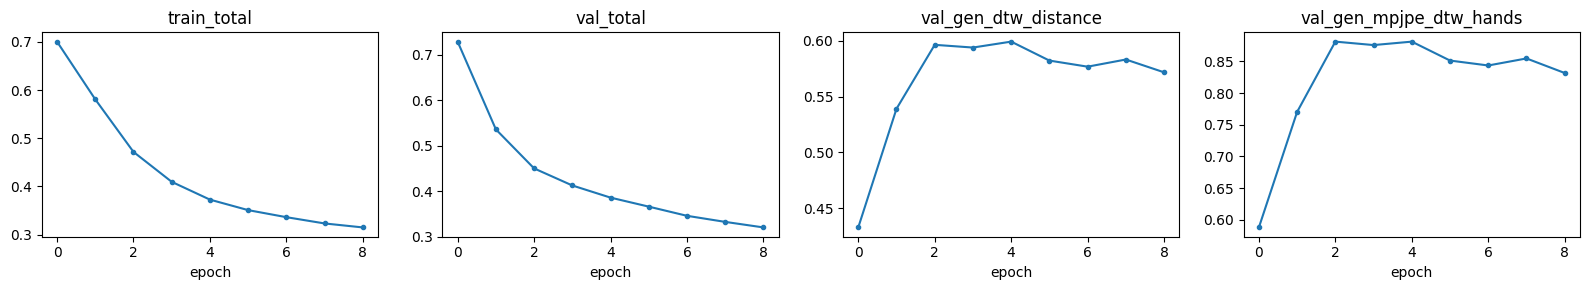

other val keys: ['val_acceleration', 'val_bone', 'val_counter', 'val_feat', 'val_gen_dtw_distance', 'val_gen_hand_shape_error_dtw', 'val_gen_length_ratio', 'val_gen_motion_energy_ratio', 'val_gen_mpjpe_dtw', 'val_gen_mpjpe_dtw_body', 'val_gen_mpjpe_dtw_face', 'val_gen_mpjpe_dtw_hands', 'val_gen_mpjpe_resampled', 'val_gen_pck@0.1', 'val_gen_pck@0.2', 'val_gen_velocity_error', 'val_pose', 'val_total', 'val_velocity']


In [9]:
import matplotlib.pyplot as plt
recs = [json.loads(l) for l in open(f'{OUT}/metrics.jsonl')]
show = ['train_total', 'val_total', 'val_gen_dtw_distance', 'val_gen_mpjpe_dtw_hands']
show = [k for k in show if k in recs[0]]
print('epoch ' + ' '.join(f'{k:>24}' for k in show) + '  best')
for r in recs:
    print(f"{r['epoch']:>5} " + ' '.join(f'{r[k]:>24.4f}' for k in show) + ('  *' if r.get('improved') else ''))
fig, axes = plt.subplots(1, len(show), figsize=(4 * len(show), 3))
for ax, k in zip(axes, show):
    ax.plot([r['epoch'] for r in recs], [r[k] for r in recs], marker='.')
    ax.set_title(k); ax.set_xlabel('epoch')
plt.tight_layout(); plt.show()
print('other val keys:', sorted(k for k in recs[-1] if k.startswith('val')))

## 10. Evaluate on val

`evaluate.py` generates free-running poses for every val clip, scores them against the ground truth and against a static mean-pose baseline, and — with the SLT evaluator — back-translates both the generated and the ground-truth poses. Generated-pose BLEU only means something next to the ground-truth-pose BLEU on the same clips.

The seen / unseen table splits clips by whether their sentence occurs in train. Unseen is the number that measures generalisation.

In [10]:
def evaluate(split):
    out_dir = f'{OUT}/eval_{split}'
    if os.path.exists(f'{out_dir}/metrics.json'):
        print('already evaluated:', out_dir)
    else:
        cmd = [sys.executable, '-u', 'evaluate.py', '--checkpoint', f'{OUT}/best.pt', '--split', split,
               '--device', DEVICE, '--out-dir', out_dir, '--render-n', '6']
        if SLT_CKPT:
            cmd += ['--slr-checkpoint', SLT_CKPT]
        if run(cmd, log_path=f'{OUT}/eval_{split}.log') != 0:
            raise SystemExit(f'evaluate.py failed on {split}')
    return out_dir

def norm_text(t):
    return ' '.join(''.join(c for c in t.lower() if c.isalnum() or c == ' ').split())

def seen_unseen(out_dir):
    import sacrebleu, warnings, numpy as np
    warnings.filterwarnings('ignore', category=RuntimeWarning)   # nanmean over an all-NaN column
    with open(f"{CFG['data']['split_dir']}/train.csv", newline='', encoding='utf-8') as fh:
        train_text = {norm_text(r['text']) for r in csv.DictReader(fh)}
    with open(f'{out_dir}/per_sample.csv', newline='', encoding='utf-8') as fh:
        per = list(csv.DictReader(fh))
    groups = {'all': per,
              'seen': [r for r in per if norm_text(r['text']) in train_text],
              'unseen': [r for r in per if norm_text(r['text']) not in train_text]}
    cols = ['dtw_distance', 'mpjpe_dtw', 'mpjpe_dtw_hands', 'hand_shape_error_dtw']
    print(f"{'group':<7}{'n':>6}" + ''.join(f'{c:>22}' for c in cols)
          + (f"{'BT-BLEU gen':>13}{'BT-BLEU gt':>12}{'chrF gen':>10}{'chrF gt':>9}" if 'bt_generated' in per[0] else ''))
    for g, rows in groups.items():
        if not rows:
            continue
        line = f'{g:<7}{len(rows):>6}' + ''.join(f"{np.nanmean([float(r[c]) for r in rows if r.get(c) not in ('', None)]):>22.4f}" for c in cols)
        if 'bt_generated' in rows[0]:
            refs = [[r['text'] for r in rows]]
            bg = sacrebleu.corpus_bleu([r['bt_generated'] for r in rows], refs, force=True).score
            br = sacrebleu.corpus_bleu([r['bt_reference'] for r in rows], refs, force=True).score
            cg = sacrebleu.corpus_chrf([r['bt_generated'] for r in rows], refs).score
            cr = sacrebleu.corpus_chrf([r['bt_reference'] for r in rows], refs).score
            line += f'{bg:>13.2f}{br:>12.2f}{cg:>10.2f}{cr:>9.2f}'
        print(line)

VAL_DIR = evaluate('val')
m = json.load(open(f'{VAL_DIR}/metrics.json'))
print(json.dumps({k: m[k] for k in ('n', 'beats_mean_pose_baseline')}, indent=1))
for k in ('dtw_distance', 'mpjpe_dtw', 'mpjpe_dtw_hands', 'hand_shape_error_dtw'):
    if k in m['model']:
        print(f"{k:<22} model {m['model'][k]:.4f} | mean-pose baseline {m['mean_pose_baseline'][k]:.4f}")
print({k: round(v, 3) for k, v in m['model'].items() if 'energy' in k or 'ratio' in k})
if 'back_translation' in m:
    print('back-translation:', json.dumps(m['back_translation'], indent=1))
print()
seen_unseen(VAL_DIR)

[dataset] 7/792 samples have no preprocessed pose (rejected or not run); skipped
  evaluated 16/785
  evaluated 32/785
  evaluated 48/785
  evaluated 64/785
  evaluated 80/785
  evaluated 96/785
  evaluated 112/785
  evaluated 128/785
  evaluated 144/785
  evaluated 160/785
  evaluated 176/785
  evaluated 192/785
  evaluated 208/785
  evaluated 224/785
  evaluated 240/785
  evaluated 256/785
  evaluated 272/785
  evaluated 288/785
  evaluated 304/785
  evaluated 320/785
  evaluated 336/785
  evaluated 352/785
  evaluated 368/785
  evaluated 384/785
  evaluated 400/785
  evaluated 416/785
  evaluated 432/785
  evaluated 448/785
  evaluated 464/785
  evaluated 480/785
  evaluated 496/785
  evaluated 512/785
  evaluated 528/785
  evaluated 544/785
  evaluated 560/785
  evaluated 576/785
  evaluated 592/785
  evaluated 608/785
  evaluated 624/785
  evaluated 640/785
  evaluated 656/785
  evaluated 672/785
  evaluated 688/785
  evaluated 704/785
  evaluated 720/785
  evaluated 736/785
  eva

Side-by-side renders (generated left, ground truth right) for the first val clips. OpenCV writes `mp4v`, which browsers do not play, so they are re-encoded to H.264 for display.

In [11]:
from IPython.display import Video, display
def show_videos(pattern, n=3):
    os.makedirs('/content/preview', exist_ok=True)
    for src in sorted(glob.glob(pattern))[:n]:
        dst = f'/content/preview/{os.path.basename(src)}'
        subprocess.run(['ffmpeg', '-y', '-loglevel', 'error', '-i', src, '-vcodec', 'libx264', '-pix_fmt', 'yuv420p', dst], check=True)
        print(os.path.basename(src))
        display(Video(dst, embed=True, width=640))
show_videos(f'{VAL_DIR}/*_compare.mp4')

ad-communication-video_1_15_compare.mp4


ad-communication-video_1_34_compare.mp4


ad-communication-video_1_38_compare.mp4


## 11. Test (run once, at the end)

Kept behind a flag: choose the checkpoint and settings on val first, then score test once. Test includes the 12 clips on the exclusion list, as in the SLT test protocol.

In [12]:
RUN_TEST = False
if RUN_TEST:
    TEST_DIR = evaluate('test')
    m = json.load(open(f'{TEST_DIR}/metrics.json'))
    print(json.dumps({k: m[k] for k in ('n', 'model', 'mean_pose_baseline', 'beats_mean_pose_baseline')}, indent=1))
    if 'back_translation' in m:
        print(json.dumps(m['back_translation'], indent=1))
    seen_unseen(TEST_DIR)
else:
    print('RUN_TEST is False')

RUN_TEST is False


## 12. Generate from new everyday sentences

In [13]:
SENTENCES = [
    'hello , how are you ?',
    'what is your name ?',
    'i am hungry , let us eat .',
    'thank you very much .',
    'see you tomorrow .',
]
DEMO = f'{OUT}/demo'
os.makedirs(DEMO, exist_ok=True)
for i, s in enumerate(SENTENCES):
    dst = f'{DEMO}/{i:02d}.mp4'
    if not os.path.exists(dst):
        rc = run([sys.executable, 'infer.py', '--checkpoint', f'{OUT}/best.pt', '--text', s, '--output', dst, '--device', DEVICE])
        if rc != 0:
            raise SystemExit(f'infer.py failed on {s!r}')
    print(i, s)
show_videos(f'{DEMO}/*.mp4', n=len(SENTENCES))

generated 300 frames (12.00s) -> /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/demo/00.npy  [WARNING: hit max_frames; counter never reached stop threshold]
rendered -> /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/demo/00.mp4
0 hello , how are you ?
generated 300 frames (12.00s) -> /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/demo/01.npy  [WARNING: hit max_frames; counter never reached stop threshold]
rendered -> /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/demo/01.mp4
1 what is your name ?
generated 300 frames (12.00s) -> /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/demo/02.npy  [WARNING: hit max_frames; counter never reached stop threshold]
rendered -> /content/drive/MyDrive/auslan_work/sft_runs/sft_comm__openasl__modeB__seed42/demo/02.mp4
2 i am hungry , let us eat .
generated 300 frames (12.00s) -> /content/drive/MyDrive/ausla

01.mp4


02.mp4


03.mp4


04.mp4
